# Multi-Model Comparison: Interval Detection

## Overview

This notebook provides a systematic comparison across ten interval detection models:

| Model | Type | Features |
|-------|------|----------|
| **XGBoost** | Gradient Boosting (tree-based) | Full feature set |
| **FFNN** | Feed-Forward Neural Network | Full feature set |
| **BiLSTM** | Bidirectional LSTM | Full feature set |
| **BiLSTM (reduced)** | Bidirectional LSTM | Reduced feature set |
| **TCN** | Temporal Convolutional Network (dilated) | Full feature set |
| **TCN (reduced)** | Temporal Convolutional Network (dilated) | Reduced feature set |
| **CNN** | Convolutional Neural Network (improved) | Full feature set |
| **CNN (reduced)** | Convolutional Neural Network (improved) | Reduced feature set |
| **U-Net** | 1D U-Net (encoder-decoder with skip connections) | Full feature set |
| **U-Net (reduced)** | 1D U-Net (encoder-decoder with skip connections) | Reduced feature set |

All models were evaluated on the same set of athletic training sessions using a **leave-one-session-out** cross-validation strategy. Each session is held out as a test set while the remaining sessions are used for training.

### Evaluation Metrics

| Metric | Description |
|--------|-------------|
| **F_beta** | Weighted harmonic mean of precision and recall (primary metric) |
| **Precision** | Fraction of predicted intervals that are correct (fewer false positives = higher precision) |
| **Recall** | Fraction of true intervals that were detected (fewer missed intervals = higher recall) |
| **MAE (seconds)** | Mean absolute timing error between predicted and true interval boundaries |

In [1]:
# ============================================================================
# MULTI-MODEL COMPARISON ANALYSIS
# ============================================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("=" * 70)
print("MULTI-MODEL COMPARISON ANALYSIS")
print("=" * 70)

# ============================================================================
# 1. DEFINE AND LOAD ALL MODELS
# ============================================================================

MODELS = OrderedDict([
    ('XGBoost',          'results/xgboost_results.pkl'),
    ('FFNN',             'results/FFNN_results.pkl'),
    ('BiLSTM',           'results/bilstm_results.pkl'),
    ('BiLSTM (reduced)', 'results/bilstm_reduced_results.pkl'),
    ('TCN',              'results/tcn_dilated_results.pkl'),
    ('TCN (reduced)',    'results/tcn_dilated_reduced_results.pkl'),
    ('CNN',              'results/cnn_improved_results.pkl'),
    ('CNN (reduced)',    'results/cnn_improved_reduced_results.pkl'),
    ('U-Net',            'results/unet_1d_results.pkl'),
    ('U-Net (reduced)',  'results/unet_1d_reduced_results.pkl'),
])

MODEL_STYLES = {
    'XGBoost':          {'color': '#1f77b4', 'marker': 's'},
    'FFNN':             {'color': '#ff7f0e', 'marker': 'o'},
    'BiLSTM':           {'color': '#2ca02c', 'marker': '^'},
    'BiLSTM (reduced)': {'color': '#98df8a', 'marker': 'v'},
    'TCN':              {'color': '#d62728', 'marker': 'D'},
    'TCN (reduced)':    {'color': '#ff9896', 'marker': 'd'},
    'CNN':              {'color': '#9467bd', 'marker': 'P'},
    'CNN (reduced)':    {'color': '#c5b0d5', 'marker': 'X'},
    'U-Net':            {'color': '#8c564b', 'marker': 'h'},
    'U-Net (reduced)':  {'color': '#c49c94', 'marker': 'H'},
}

# Load all results
all_results = {}  # {model_name: {session_id: result_dict}}
print("\nLoading models:")
for name, path in MODELS.items():
    with open(path, 'rb') as f:
        package = pickle.load(f)
    results_list = package['results']
    all_results[name] = {res['session']: res for res in results_list}
    print(f"  {name}: {len(results_list)} sessions")

# Find common sessions across ALL models
all_session_sets = [set(d.keys()) for d in all_results.values()]
common_sessions = set.intersection(*all_session_sets)
print(f"\nCommon sessions across all {len(MODELS)} models: {len(common_sessions)}")

for name in MODELS:
    extra = set(all_results[name].keys()) - common_sessions
    if extra:
        print(f"  {name} extra sessions (excluded): {len(extra)}")

# ============================================================================
# 2. BUILD LONG-FORMAT COMPARISON DATAFRAME
# ============================================================================

rows = []
for session_id in sorted(common_sessions):
    ref_res = all_results['XGBoost'][session_id]
    df_session = ref_res['df']

    sport = ref_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in ref_res['athlete'] or 'Zwift' in session_id:
            sport = 'biking'
        else:
            sport = 'rowing'

    for model_name in MODELS:
        res = all_results[model_name][session_id]
        rows.append({
            'session': session_id,
            'athlete': ref_res['athlete'],
            'sport': sport,
            'n_intervals': ref_res['n_true'],
            'duration_sec': len(df_session),
            'model': model_name,
            'f_beta': res['f_beta'],
            'precision': res['precision'],
            'recall': res['recall'],
            'mae': res.get('mean_error_sec', np.nan),
            'n_pred': res['n_pred'],
            'n_true': res['n_true'],
        })

df_long = pd.DataFrame(rows)
df_long['complexity'] = pd.cut(
    df_long['n_intervals'],
    bins=[0, 10, 20, 100],
    labels=['Low (<=10)', 'Medium (11-20)', 'High (>20)']
)

print(f"\nDataframe: {len(df_long)} rows "
      f"({len(common_sessions)} sessions x {len(MODELS)} models)")

# ============================================================================
# 3. OVERALL PERFORMANCE RANKING
# ============================================================================

print("\n" + "=" * 70)
print("OVERALL PERFORMANCE RANKING (sorted by mean F_beta)")
print("=" * 70)

overall_stats = df_long.groupby('model').agg(
    F_beta_mean=('f_beta', 'mean'),
    F_beta_std=('f_beta', 'std'),
    Precision_mean=('precision', 'mean'),
    Recall_mean=('recall', 'mean'),
    MAE_mean=('mae', 'mean'),
).round(3).sort_values('F_beta_mean', ascending=False)

overall_stats.index.name = 'Model'
model_order = overall_stats.index.tolist()
print()
display(overall_stats)

# ============================================================================
# 4. BEST MODEL PER SESSION
# ============================================================================

print("\n" + "=" * 70)
print("BEST MODEL PER SESSION (by F_beta)")
print("=" * 70)

best_per_session = df_long.loc[df_long.groupby('session')['f_beta'].idxmax()]
win_counts = best_per_session['model'].value_counts()

print("\nSessions where each model achieved highest F_beta:")
for model, count in win_counts.items():
    pct = 100 * count / len(common_sessions)
    print(f"  {model}: {count} ({pct:.1f}%)")

# ============================================================================
# 5. BREAKDOWN BY SPORT
# ============================================================================

print("\n" + "=" * 70)
print("MEAN F_BETA BY SPORT")
print("=" * 70)

sport_table = df_long.pivot_table(
    values='f_beta', index='model', columns='sport', aggfunc='mean'
).round(3).loc[model_order]
print()
display(sport_table)

# ============================================================================
# 6. BREAKDOWN BY COMPLEXITY
# ============================================================================

print("\n" + "=" * 70)
print("MEAN F_BETA BY COMPLEXITY")
print("=" * 70)

comp_table = df_long.pivot_table(
    values='f_beta', index='model', columns='complexity',
    aggfunc='mean', observed=False
).round(3).loc[model_order]
print()
display(comp_table)

# ============================================================================
# 7. SESSION-BY-SESSION: BEST AND WORST MODELS
# ============================================================================

print("\n" + "=" * 70)
print("SESSION-BY-SESSION: BEST AND WORST MODELS")
print("=" * 70)

fbeta_wide = df_long.pivot_table(values='f_beta', index='session', columns='model')

print(f"\n{'Session':<48} {'Best Model':<20} {'Score':>6}  {'Worst Model':<20} {'Score':>6}")
print("-" * 110)
for session_id in sorted(common_sessions):
    row = fbeta_wide.loc[session_id]
    best_m = row.idxmax()
    worst_m = row.idxmin()
    s = session_id[:45] + "..." if len(session_id) > 48 else session_id
    print(f"  {s:<48} {best_m:<20} {row.max():>6.3f}  {worst_m:<20} {row.min():>6.3f}")

print("\n" + "=" * 70)
print("DATA LOADING COMPLETE")
print("=" * 70)

MULTI-MODEL COMPARISON ANALYSIS

Loading models:
  XGBoost: 18 sessions
  FFNN: 18 sessions
  BiLSTM: 18 sessions
  BiLSTM (reduced): 18 sessions
  TCN: 18 sessions
  TCN (reduced): 18 sessions
  CNN: 18 sessions
  CNN (reduced): 18 sessions
  U-Net: 18 sessions
  U-Net (reduced): 18 sessions

Common sessions across all 10 models: 18

Dataframe: 180 rows (18 sessions x 10 models)

OVERALL PERFORMANCE RANKING (sorted by mean F_beta)



,F_beta_mean,F_beta_std,Precision_mean,Recall_mean,MAE_mean
Model,,,,,
FFNN,0.714,0.156,0.715,0.713,18.340
XGBoost,0.708,0.171,0.711,0.707,17.540
U-Net,0.696,0.165,0.688,0.701,40.705
CNN,0.691,0.147,0.685,0.693,24.256
TCN,0.687,0.162,0.686,0.687,24.641
U-Net (reduced),0.624,0.187,0.620,0.627,46.555
TCN (reduced),0.598,0.188,0.594,0.601,59.105
BiLSTM,0.589,0.131,0.586,0.591,32.283
CNN (reduced),0.561,0.135,0.556,0.564,58.478



BEST MODEL PER SESSION (by F_beta)

Sessions where each model achieved highest F_beta:
  FFNN: 7 (38.9%)
  XGBoost: 7 (38.9%)
  TCN: 2 (11.1%)
  TCN (reduced): 1 (5.6%)
  U-Net: 1 (5.6%)

MEAN F_BETA BY SPORT



sport,biking,rowing
model,,
FFNN,0.661,0.740
XGBoost,0.594,0.765
U-Net,0.615,0.736
CNN,0.625,0.724
TCN,0.607,0.727
U-Net (reduced),0.449,0.711
TCN (reduced),0.504,0.645
BiLSTM,0.534,0.617
CNN (reduced),0.479,0.603



MEAN F_BETA BY COMPLEXITY



complexity,Low (<=10),Medium (11-20),High (>20)
model,,,
FFNN,0.705,0.759,0.663
XGBoost,0.731,0.737,0.617
U-Net,0.665,0.758,0.663
CNN,0.690,0.745,0.611
TCN,0.675,0.757,0.605
U-Net (reduced),0.690,0.617,0.503
TCN (reduced),0.625,0.672,0.434
BiLSTM,0.559,0.635,0.581
CNN (reduced),0.551,0.579,0.556



SESSION-BY-SESSION: BEST AND WORST MODELS

Session                                          Best Model            Score  Worst Model           Score
--------------------------------------------------------------------------------------------------------------
  10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Wat... CNN                   0.750  BiLSTM                0.500
  11783093951_4x2000_sub8                          FFNN                  0.778  BiLSTM                0.333
  11846980624_Platt_                               XGBoost               0.900  BiLSTM (reduced)      0.600
  11962243206_Wundmanagement                       FFNN                  1.000  BiLSTM (reduced)      0.667
  12036692734_Exhausted                            TCN (reduced)         0.778  BiLSTM                0.556
  12069656901_Schwitzen_im_Sitzen                  XGBoost               0.714  BiLSTM (reduced)      0.143
  12846436186_Synchronflug                         CNN                   1.000  BiLSTM (red

## Interpretation: Overall Comparison

### Overall Ranking

**FFNN** and **XGBoost** lead the field with mean F_beta scores of 0.714 and 0.708, respectively. They are closely followed by **U-Net** (0.696), **CNN** (0.691), and **TCN** (0.687), forming a competitive top-5 tier. The remaining five models -- all either reduced-feature variants or BiLSTM -- fall noticeably behind, with F_beta values ranging from 0.524 to 0.624.

### Best Model Per Session

FFNN and XGBoost each win 7 out of 18 sessions (38.9% each), together dominating 77.8% of all sessions. TCN wins 2 sessions (11.1%), while TCN (reduced) and U-Net each win 1 session. Notably, none of the remaining five models (BiLSTM, BiLSTM reduced, CNN, CNN reduced, U-Net reduced) are ever the top performer on any session.

### By Sport

All models perform better on **rowing** than on **biking**. The gap is particularly large for XGBoost (0.765 rowing vs 0.594 biking, a difference of 0.171) and U-Net reduced (0.711 vs 0.449, difference of 0.262). FFNN shows the smallest sport gap among top models (0.740 vs 0.661, difference of 0.079), making it the most sport-agnostic choice.

### By Complexity

Most models achieve their best scores on **medium-complexity** sessions (11--20 intervals), with FFNN leading at 0.759 and U-Net/TCN close behind at 0.758/0.757. Performance generally drops on high-complexity sessions (>20 intervals), where FFNN and U-Net share the best score (0.663). XGBoost dominates low-complexity sessions (0.731) but drops more steeply at high complexity (0.617).

### Full vs Reduced Features

Across all four architectures tested in both variants (BiLSTM, TCN, CNN, U-Net), the **full feature set always outperforms the reduced set**. The largest gap is CNN (0.691 vs 0.561, -0.129), and the smallest is BiLSTM (0.589 vs 0.524, -0.065). This indicates that the additional features provide meaningful signal that all architectures can leverage.

### Session-by-Session Best/Worst

Some sessions are consistently easy: e.g., session "Synchronflug" where the best model (CNN) achieves a perfect 1.000 and even the worst (BiLSTM reduced) scores 0.333. Other sessions reveal stark model differences: on "Schwitzen_im_Sitzen", XGBoost scores 0.714 while BiLSTM (reduced) scores only 0.143 -- a gap of 0.571. Two sessions achieve a perfect 1.000 from at least one model ("Wundmanagement" by FFNN, "Synchronflug" by CNN).

## Detailed Summary Tables

In [2]:
# ============================================================================
# SUMMARY TABLES
# ============================================================================

metrics = ['f_beta', 'precision', 'recall', 'mae']
metric_labels = ['F_beta', 'Precision', 'Recall', 'MAE (sec)']

# ── Table 1: All metrics for all models ──
print("=" * 60)
print("TABLE 1: Overall Metrics per Model")
print("=" * 60)

table1_rows = []
for model in model_order:
    mdf = df_long[df_long['model'] == model]
    table1_rows.append({
        'Model': model,
        'F_beta': mdf['f_beta'].mean(),
        'Precision': mdf['precision'].mean(),
        'Recall': mdf['recall'].mean(),
        'MAE (sec)': mdf['mae'].mean(),
    })
table1 = pd.DataFrame(table1_rows).set_index('Model').round(3)
display(table1)

# ── Table 2: F_beta per model per sport ──
print("\n" + "=" * 60)
print("TABLE 2: Metrics per Model per Sport")
print("=" * 60)

for metric, label in zip(metrics, metric_labels):
    print(f"\n--- {label} ---")
    pivot = df_long.pivot_table(
        values=metric, index='model', columns='sport', aggfunc='mean'
    ).round(3).loc[model_order]
    display(pivot)

# ── Table 3: F_beta per model per complexity ──
print("\n" + "=" * 60)
print("TABLE 3: Metrics per Model per Complexity")
print("=" * 60)

for metric, label in zip(metrics, metric_labels):
    print(f"\n--- {label} ---")
    pivot = df_long.pivot_table(
        values=metric, index='model', columns='complexity',
        aggfunc='mean', observed=False
    ).round(3).loc[model_order]
    display(pivot)

# ── Table 4: Win counts by sport and complexity ──
print("\n" + "=" * 60)
print("TABLE 4: Win Counts (sessions where model is best)")
print("=" * 60)

best = df_long.loc[df_long.groupby('session')['f_beta'].idxmax()]

print("\nBy Sport:")
win_sport = best.pivot_table(
    index='model', columns='sport', values='session',
    aggfunc='count', fill_value=0
)
win_sport['Total'] = win_sport.sum(axis=1)
win_sport = win_sport.sort_values('Total', ascending=False)
display(win_sport)

print("\nBy Complexity:")
win_comp = best.pivot_table(
    index='model', columns='complexity', values='session',
    aggfunc='count', fill_value=0, observed=False
)
win_comp['Total'] = win_comp.sum(axis=1)
win_comp = win_comp.sort_values('Total', ascending=False)
display(win_comp)

TABLE 1: Overall Metrics per Model


,F_beta,Precision,Recall,MAE (sec)
Model,,,,
FFNN,0.714,0.715,0.713,18.340
XGBoost,0.708,0.711,0.707,17.540
U-Net,0.696,0.688,0.701,40.705
CNN,0.691,0.685,0.693,24.256
TCN,0.687,0.686,0.687,24.641
U-Net (reduced),0.624,0.620,0.627,46.555
TCN (reduced),0.598,0.594,0.601,59.105
BiLSTM,0.589,0.586,0.591,32.283
CNN (reduced),0.561,0.556,0.564,58.478



TABLE 2: Metrics per Model per Sport

--- F_beta ---


sport,biking,rowing
model,,
FFNN,0.661,0.740
XGBoost,0.594,0.765
U-Net,0.615,0.736
CNN,0.625,0.724
TCN,0.607,0.727
U-Net (reduced),0.449,0.711
TCN (reduced),0.504,0.645
BiLSTM,0.534,0.617
CNN (reduced),0.479,0.603



--- Precision ---


...

complexity,Low (<=10),Medium (11-20),High (>20)
model,,,
FFNN,23.687,10.964,18.709
XGBoost,14.677,21.864,16.779
U-Net,65.159,27.144,12.138
CNN,27.309,18.020,27.505
TCN,31.665,18.635,19.602
U-Net (reduced),49.740,49.062,36.425
TCN (reduced),84.166,37.878,40.822
BiLSTM,35.321,26.274,35.219
CNN (reduced),84.663,35.735,40.225



TABLE 4: Win Counts (sessions where model is best)

By Sport:


sport,biking,rowing,Total
model,,,
FFNN,3,4,7
XGBoost,2,5,7
TCN,1,1,2
TCN (reduced),0,1,1
U-Net,0,1,1



By Complexity:


complexity,Low (<=10),Medium (11-20),High (>20),Total
model,,,,
FFNN,2,3,2,7
XGBoost,5,1,1,7
TCN,0,1,1,2
TCN (reduced),1,0,0,1
U-Net,0,1,0,1


## Interpretation: Summary Tables

### Table 1 -- Overall Metrics per Model

FFNN and XGBoost lead across all four metrics. Their precision and recall are nearly balanced (FFNN: 0.715 / 0.713; XGBoost: 0.711 / 0.707), meaning neither model is systematically biased toward over- or under-predicting intervals. U-Net ranks third in F_beta (0.696) but has a considerably worse MAE (40.7 s), suggesting that while it finds the right number of intervals, the predicted boundaries are less precisely timed. Among the bottom-5 models, TCN (reduced) and CNN (reduced) stand out with very high MAE values (59.1 s and 58.5 s), indicating poor timing accuracy on top of weak detection performance.

### Table 2 -- Metrics by Sport

**F_beta:** All models perform better on rowing than on biking. FFNN leads biking (0.661) while XGBoost leads rowing (0.765). The largest sport gap belongs to U-Net (reduced), which drops from 0.711 on rowing to just 0.449 on biking.

**Precision:** XGBoost achieves the highest rowing precision (0.764), while FFNN leads biking precision (0.663). The reduced-feature models show notably lower precision on biking (all below 0.51), suggesting they produce many false positives on cycling sessions.

**Recall:** The pattern mirrors precision closely. XGBoost achieves the highest rowing recall (0.765) and FFNN the highest biking recall (0.660). BiLSTM (reduced) has the worst biking recall (0.458), missing more than half of all true intervals.

**MAE:** XGBoost has the best timing accuracy on rowing (15.5 s), while FFNN has the best on biking (20.4 s). U-Net (reduced) has the worst biking MAE (68.6 s), meaning its predicted interval boundaries are off by over a minute on average for cycling sessions.

### Table 3 -- Metrics by Complexity

**F_beta:** Medium-complexity sessions (11--20 intervals) yield the highest scores for most models, with FFNN (0.759), U-Net (0.758), and TCN (0.757) nearly tied. At high complexity (>20 intervals), FFNN and U-Net share the best score (0.663). TCN (reduced) drops to 0.434 and BiLSTM (reduced) to 0.405, making them unreliable on complex sessions.

**Precision:** FFNN maintains the highest precision at high complexity (0.679). XGBoost leads low complexity (0.731) but drops more steeply at high complexity (0.641).

**Recall:** U-Net has the best high-complexity recall (0.671), confirming its strength at finding intervals in complex sessions even if timing is less precise. BiLSTM (reduced) has the worst high-complexity recall (0.410).

**MAE:** FFNN achieves the best timing accuracy on medium-complexity sessions (11.0 s). U-Net achieves the best MAE on high-complexity sessions (12.1 s), despite its higher overall MAE. TCN (reduced) and CNN (reduced) have very poor timing on low-complexity sessions (84.2 s and 84.7 s), suggesting they over-segment simple sessions.

### Table 4 -- Win Counts

**By sport:** FFNN's 7 wins are spread across both sports (3 biking, 4 rowing), while XGBoost's 7 wins lean toward rowing (5 rowing, 2 biking). No other model wins more than 2 sessions.

**By complexity:** XGBoost dominates low-complexity sessions (5 out of 8 wins). FFNN dominates medium-complexity (3 wins) and is the only model to win multiple high-complexity sessions (2 wins). This reflects their complementary strengths: XGBoost excels on simple, well-structured sessions, while FFNN handles complexity more robustly.

In [3]:
# ============================================================================
# DETAILED METRICS
# ============================================================================

# ── 1. Model Consistency ──
print("=" * 60)
print("1. MODEL CONSISTENCY (F_beta Standard Deviation)")
print("=" * 60)

consistency = df_long.groupby('model')['f_beta'].std().round(3).sort_values()
consistency.name = 'F_beta Std Dev'
display(pd.DataFrame(consistency))
print(f"\nMost consistent:  {consistency.idxmin()} (std = {consistency.min():.3f})")
print(f"Least consistent: {consistency.idxmax()} (std = {consistency.max():.3f})")

# ── 2. Failure Rate ──
print("\n" + "=" * 60)
print("2. FAILURE RATE (sessions with F_beta < 0.5)")
print("=" * 60)

n_sessions = len(common_sessions)
failures = df_long.groupby('model')['f_beta'].apply(
    lambda g: (g < 0.5).sum()
).sort_values()
failure_pct = (failures / n_sessions * 100).round(1)
failure_df = pd.DataFrame({
    'Failures': failures,
    f'Rate (% of {n_sessions})': failure_pct
})
display(failure_df)

# ── 3. False Positive & False Negative Rates ──
print("\n" + "=" * 60)
print("3. FALSE POSITIVE & FALSE NEGATIVE RATES")
print("=" * 60)

fp_fn_rows = []
for model_name in model_order:
    model_df = df_long[df_long['model'] == model_name]
    fp_rates = []
    fn_rates = []
    for _, row in model_df.iterrows():
        tp = row['recall'] * row['n_true']
        fp = row['n_pred'] - tp
        fn = row['n_true'] - tp
        fp_rate = fp / row['n_pred'] if row['n_pred'] > 0 else 0
        fn_rate = fn / row['n_true'] if row['n_true'] > 0 else 0
        fp_rates.append(fp_rate)
        fn_rates.append(fn_rate)
    fp_fn_rows.append({
        'Model': model_name,
        'Avg FP Rate': np.mean(fp_rates),
        'Avg FN Rate': np.mean(fn_rates),
    })

fp_fn_df = pd.DataFrame(fp_fn_rows).set_index('Model').round(3)
display(fp_fn_df)

# ── 4. Full vs Reduced Feature Comparison ──
print("\n" + "=" * 60)
print("4. FULL vs REDUCED FEATURE SET COMPARISON")
print("=" * 60)

pairs = [
    ('BiLSTM', 'BiLSTM (reduced)'),
    ('TCN', 'TCN (reduced)'),
    ('CNN', 'CNN (reduced)'),
    ('U-Net', 'U-Net (reduced)'),
]

pair_rows = []
for full_name, reduced_name in pairs:
    full_scores = df_long[df_long['model'] == full_name].set_index('session')['f_beta']
    red_scores = df_long[df_long['model'] == reduced_name].set_index('session')['f_beta']

    full_mean = full_scores.mean()
    red_mean = red_scores.mean()
    diff = red_mean - full_mean

    full_wins = (full_scores > red_scores).sum()
    red_wins = (red_scores > full_scores).sum()
    ties = (full_scores == red_scores).sum()

    base = full_name.split(' ')[0]
    direction = "better" if diff > 0 else "worse" if diff < 0 else "same"

    pair_rows.append({
        'Architecture': base,
        'Full F_beta': round(full_mean, 3),
        'Reduced F_beta': round(red_mean, 3),
        'Diff (Red-Full)': round(diff, 3),
        'Full Wins': full_wins,
        'Reduced Wins': red_wins,
        'Ties': ties,
    })

    print(f"\n{base}:")
    print(f"  Full features:    {full_mean:.3f}")
    print(f"  Reduced features: {red_mean:.3f}")
    print(f"  Difference:       {diff:+.3f} (reduced is {direction})")
    print(f"  Full wins: {full_wins}, Reduced wins: {red_wins}, Ties: {ties}")

print()
display(pd.DataFrame(pair_rows).set_index('Architecture'))

1. MODEL CONSISTENCY (F_beta Standard Deviation)


,F_beta Std Dev
model,
BiLSTM,0.131
CNN (reduced),0.135
CNN,0.147
FFNN,0.156
TCN,0.162
BiLSTM (reduced),0.163
U-Net,0.165
XGBoost,0.171
U-Net (reduced),0.187



Most consistent:  BiLSTM (std = 0.131)
Least consistent: TCN (reduced) (std = 0.188)

2. FAILURE RATE (sessions with F_beta < 0.5)


,Failures,Rate (% of 18)
model,,
CNN,1,5.6
FFNN,1,5.6
TCN,1,5.6
U-Net,2,11.1
XGBoost,2,11.1
U-Net (reduced),3,16.7
BiLSTM,4,22.2
CNN (reduced),4,22.2
TCN (reduced),5,27.8



3. FALSE POSITIVE & FALSE NEGATIVE RATES


,Avg FP Rate,Avg FN Rate
Model,,
FFNN,0.287,0.287
XGBoost,0.293,0.293
U-Net,0.299,0.299
CNN,0.307,0.307
TCN,0.313,0.313
U-Net (reduced),0.373,0.373
TCN (reduced),0.399,0.399
BiLSTM,0.409,0.409
CNN (reduced),0.436,0.436



4. FULL vs REDUCED FEATURE SET COMPARISON

BiLSTM:
  Full features:    0.589
  Reduced features: 0.524
  Difference:       -0.065 (reduced is worse)
  Full wins: 9, Reduced wins: 3, Ties: 6

TCN:
  Full features:    0.687
  Reduced features: 0.598
  Difference:       -0.089 (reduced is worse)
  Full wins: 11, Reduced wins: 4, Ties: 3

CNN:
  Full features:    0.691
  Reduced features: 0.561
  Difference:       -0.129 (reduced is worse)
  Full wins: 12, Reduced wins: 2, Ties: 4

U-Net:
  Full features:    0.696
  Reduced features: 0.624
  Difference:       -0.072 (reduced is worse)
  Full wins: 10, Reduced wins: 4, Ties: 4



,Full F_beta,Reduced F_beta,Diff (Red-Full),Full Wins,Reduced Wins,Ties
Architecture,,,,,,
BiLSTM,0.589,0.524,-0.065,9,3,6
TCN,0.687,0.598,-0.089,11,4,3
CNN,0.691,0.561,-0.129,12,2,4
U-Net,0.696,0.624,-0.072,10,4,4


## Interpretation: Detailed Metrics

### Model Consistency

**BiLSTM** is the most consistent model (std = 0.131), meaning its performance is the most predictable across sessions -- though at a lower average level (F_beta = 0.589). Among the top-performing models, **CNN** is the most consistent (std = 0.147), while **XGBoost** is the least consistent (std = 0.171). The reduced-feature models TCN (reduced) (std = 0.188) and U-Net (reduced) (std = 0.187) show the highest variability overall.

### Failure Rate

**CNN, FFNN, and TCN** share the lowest failure rate, each failing on only 1 out of 18 sessions (5.6%). **XGBoost** and **U-Net** fail on 2 sessions each (11.1%). The reduced-feature models are considerably less reliable: **BiLSTM (reduced)** and **TCN (reduced)** each fail on 5 sessions (27.8%), meaning they produce more-wrong-than-right predictions on over a quarter of all sessions.

### False Positive and False Negative Rates

The FP and FN rates are symmetric for all models (equal values), indicating balanced precision and recall behavior. **FFNN** achieves the lowest error rates (0.287 each), followed by **XGBoost** (0.293) and **U-Net** (0.299). At the other extreme, **BiLSTM (reduced)** has the highest error rates (0.473 each), meaning nearly half of its predictions are wrong and nearly half of real intervals are missed.

### Full vs Reduced Feature Comparison

All four architectures perform **worse** with the reduced feature set:

- **CNN** loses the most: -0.129 in F_beta (full wins 12 out of 18 sessions).
- **TCN** loses -0.089 (full wins 11 sessions).
- **U-Net** loses -0.072 (full wins 10 sessions).
- **BiLSTM** loses the least: -0.065, but also has the most ties (6 sessions), suggesting that many of its predictions are unaffected by the feature set.

This uniformly negative impact of feature reduction indicates that the additional features provide genuinely useful information across all architectures, and none of the models are harmed by the larger input dimensionality.

GENERATING VISUALIZATIONS (saving to results/multimodel_comparison/)
  Saved: results/multimodel_comparison/overall_fbeta.png


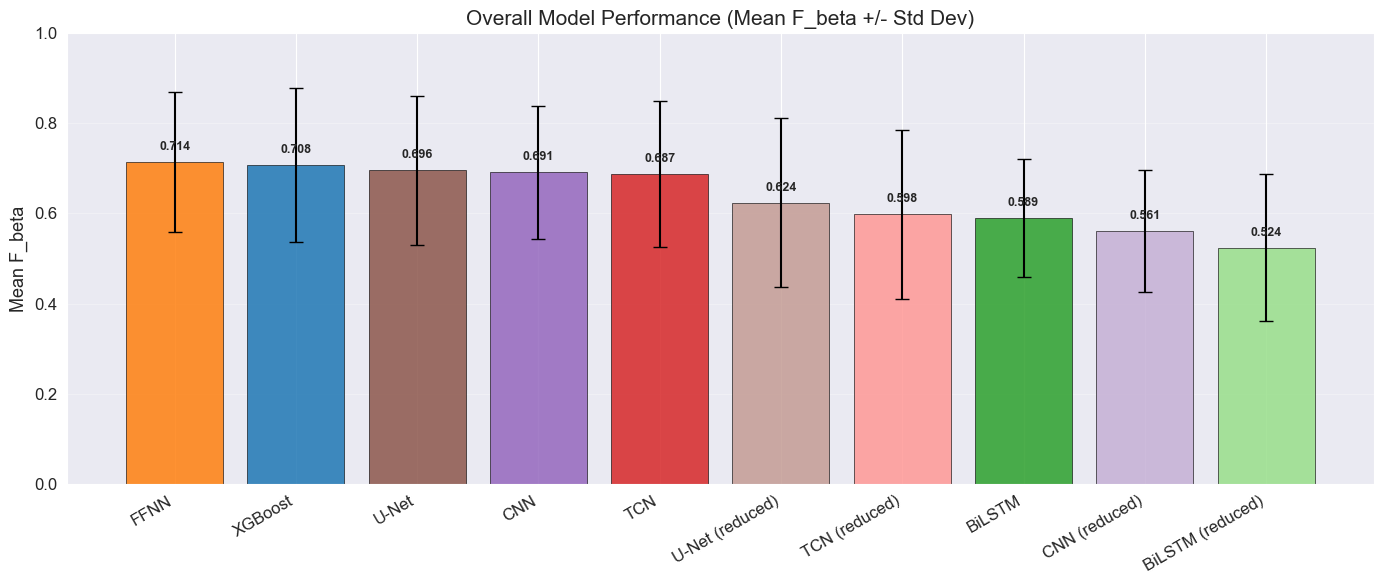

C:\Users\katha\AppData\Local\Temp\ipykernel_12744\2832673123.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_order, patch_artist=True,


  Saved: results/multimodel_comparison/fbeta_boxplot.png


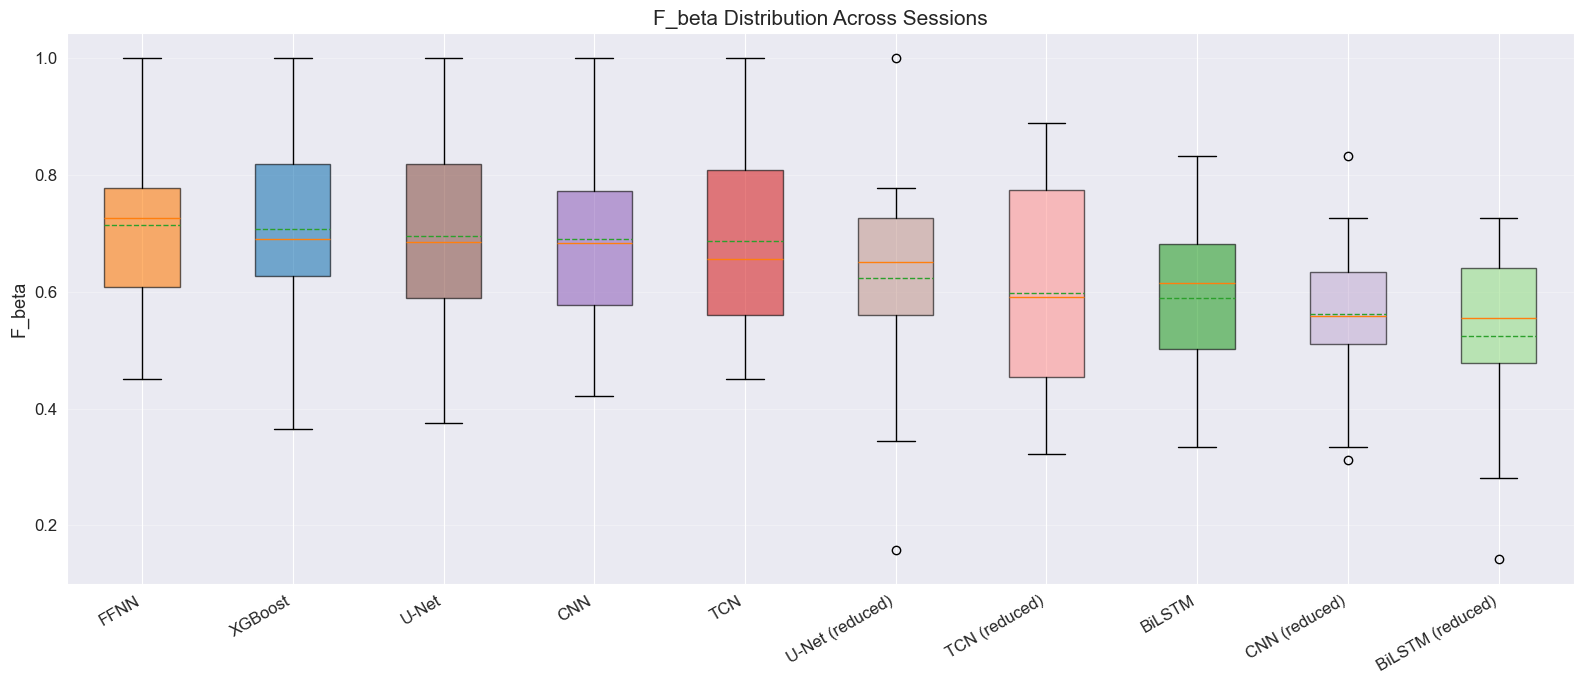

  Saved: results/multimodel_comparison/by_sport.png


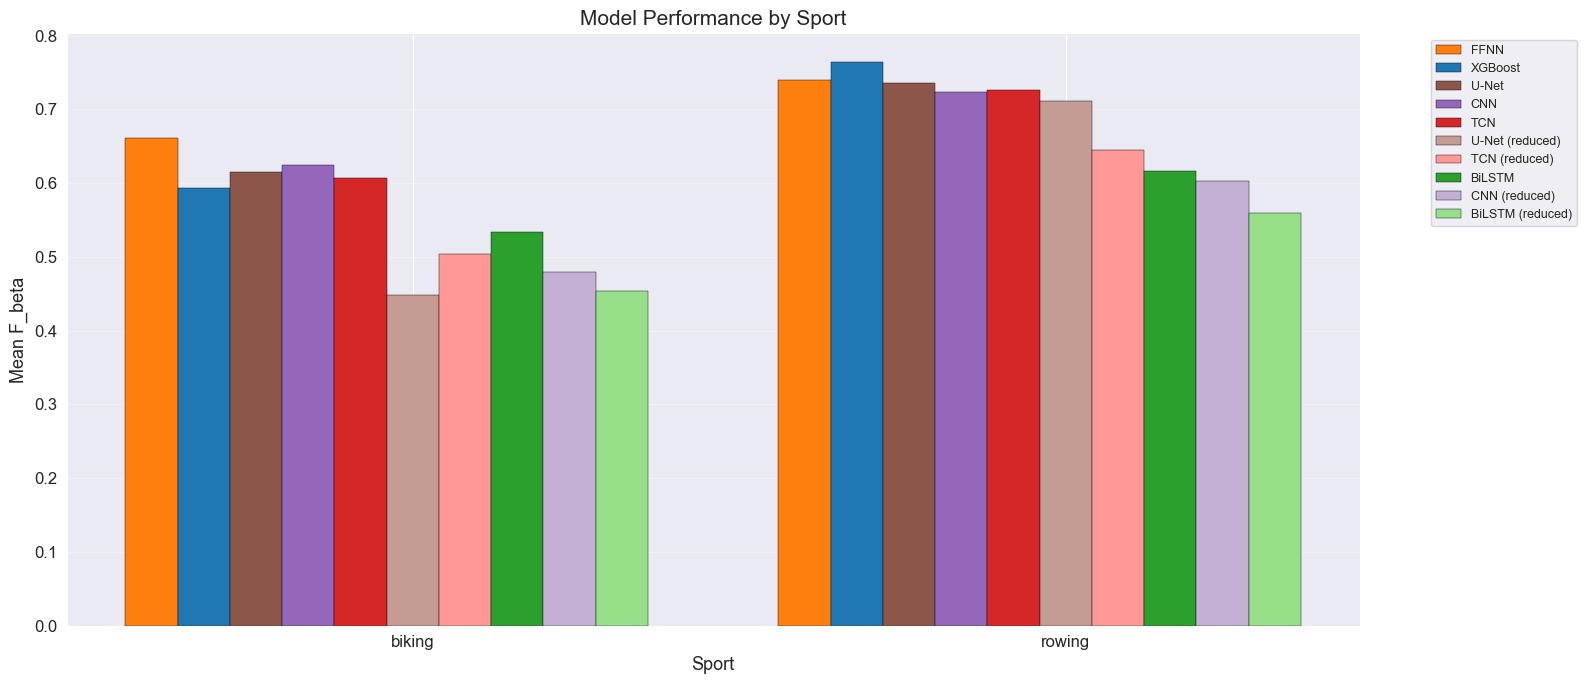

  Saved: results/multimodel_comparison/by_complexity.png


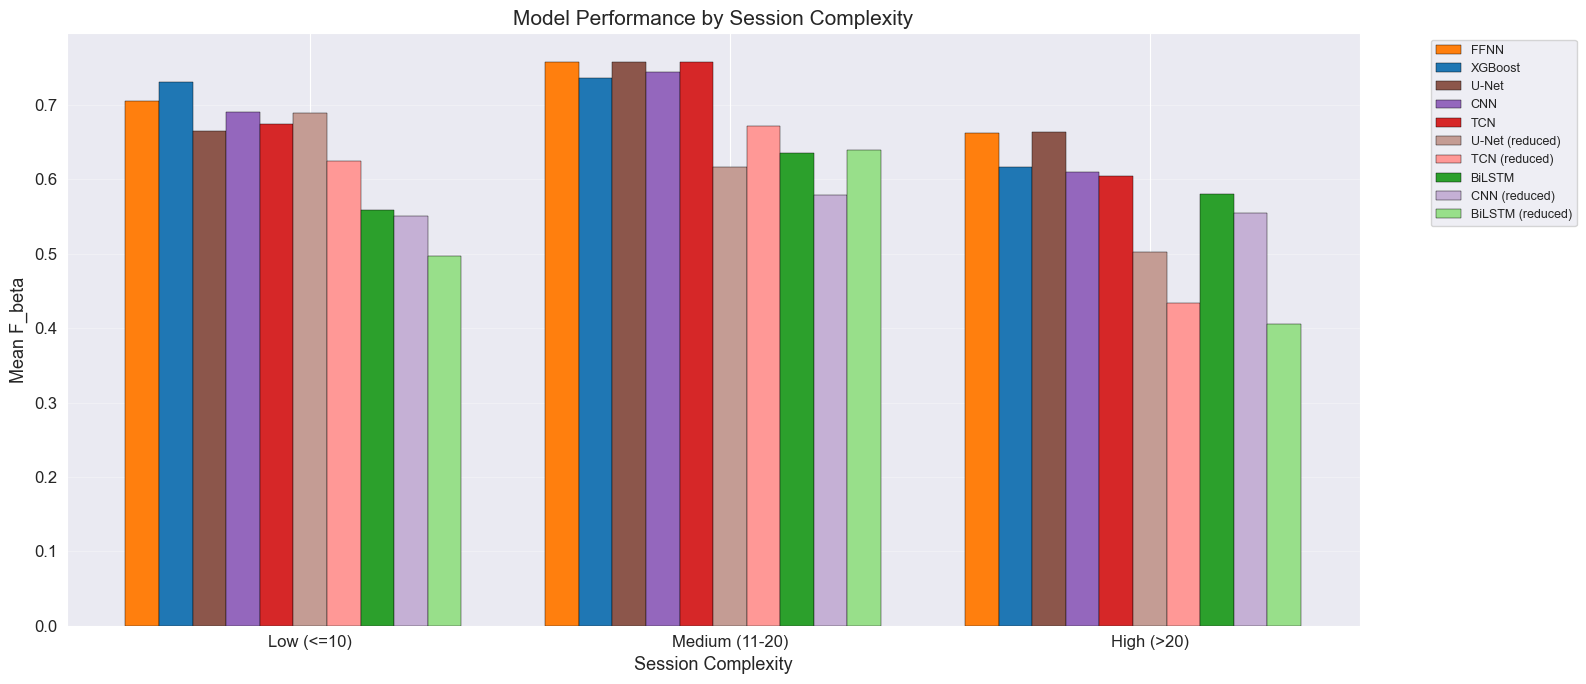

  Saved: results/multimodel_comparison/heatmap.png


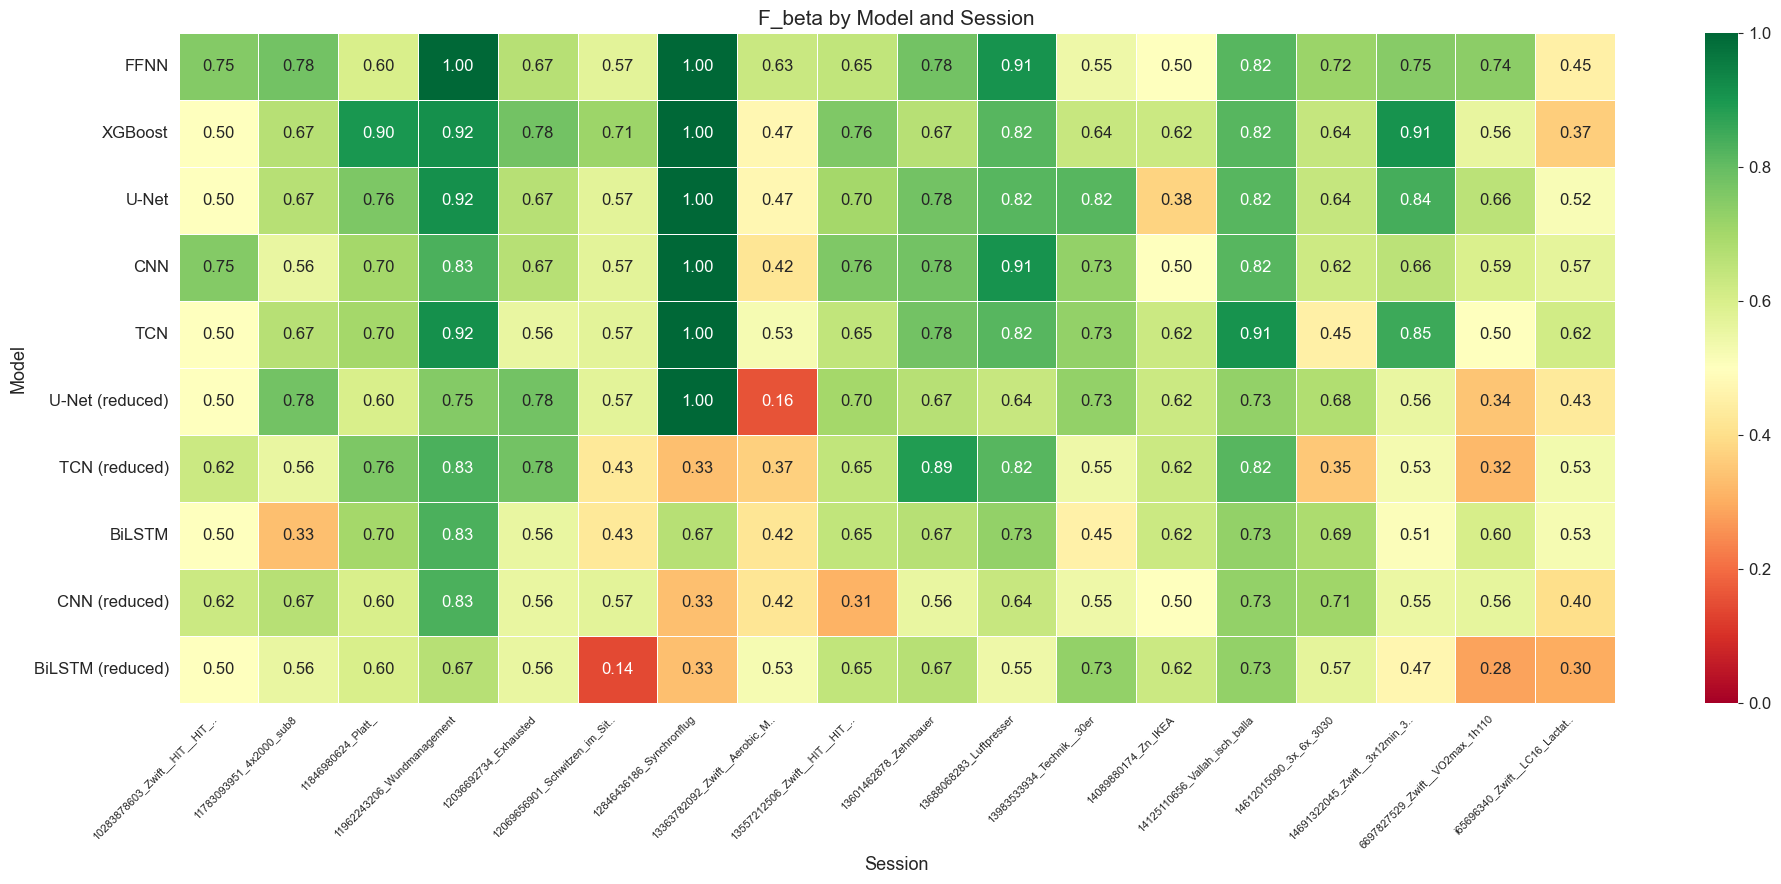

  Saved: results/multimodel_comparison/radar.png


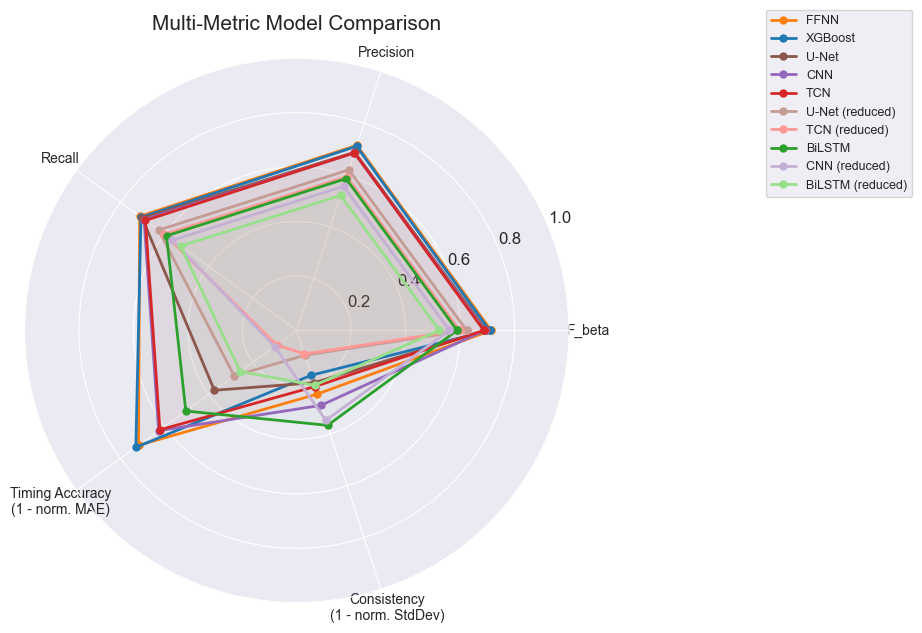

  Saved: results/multimodel_comparison/full_vs_reduced.png


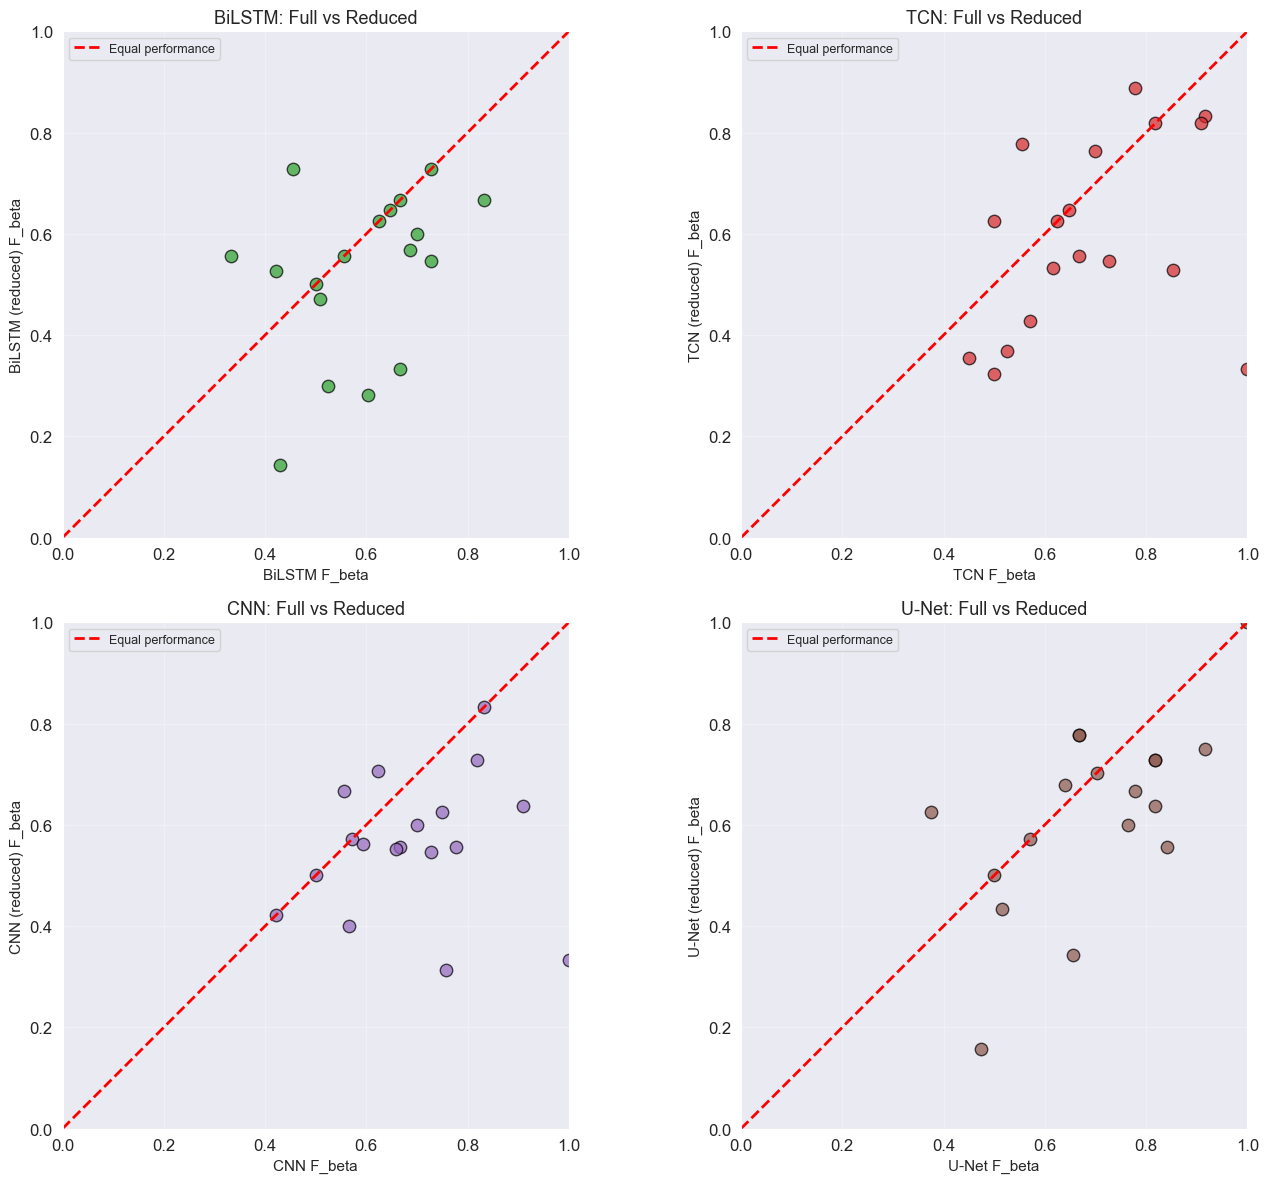


Saved: results/multimodel_comparison/multimodel_comparison.csv

VISUALIZATION COMPLETE


In [4]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

import os
SAVE_DIR = 'results/multimodel_comparison'
os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 70)
print(f"GENERATING VISUALIZATIONS (saving to {SAVE_DIR}/)")
print("=" * 70)

# ── Plot 1: Overall F_beta bar chart with error bars ──
fig, ax = plt.subplots(figsize=(14, 6))
means = [overall_stats.loc[m, 'F_beta_mean'] for m in model_order]
stds = [overall_stats.loc[m, 'F_beta_std'] for m in model_order]
colors = [MODEL_STYLES[m]['color'] for m in model_order]

bars = ax.bar(model_order, means, yerr=stds, capsize=5, color=colors,
              edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_ylabel('Mean F_beta', fontsize=13)
ax.set_title('Overall Model Performance (Mean F_beta +/- Std Dev)', fontsize=15)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/overall_fbeta.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/overall_fbeta.png")
plt.show()

# ── Plot 2: Box plots of F_beta distribution ──
fig, ax = plt.subplots(figsize=(16, 7))
data = [df_long[df_long['model'] == m]['f_beta'].values for m in model_order]
bp = ax.boxplot(data, labels=model_order, patch_artist=True,
                showmeans=True, meanline=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_ylabel('F_beta', fontsize=13)
ax.set_title('F_beta Distribution Across Sessions', fontsize=15)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fbeta_boxplot.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/fbeta_boxplot.png")
plt.show()

# ── Plot 3: Grouped bar chart by sport ──
fig, ax = plt.subplots(figsize=(16, 7))
sports = sorted(df_long['sport'].unique())
x = np.arange(len(sports))
width = 0.8 / len(model_order)

for i, model in enumerate(model_order):
    vals = [df_long[(df_long['model'] == model) & (df_long['sport'] == s)]['f_beta'].mean()
            for s in sports]
    ax.bar(x + i * width, vals, width, label=model,
           color=MODEL_STYLES[model]['color'], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Sport', fontsize=13)
ax.set_ylabel('Mean F_beta', fontsize=13)
ax.set_title('Model Performance by Sport', fontsize=15)
ax.set_xticks(x + width * len(model_order) / 2)
ax.set_xticklabels(sports)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/by_sport.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/by_sport.png")
plt.show()

# ── Plot 4: Grouped bar chart by complexity ──
fig, ax = plt.subplots(figsize=(16, 7))
comp_labels = ['Low (<=10)', 'Medium (11-20)', 'High (>20)']
x = np.arange(len(comp_labels))
width = 0.8 / len(model_order)

for i, model in enumerate(model_order):
    vals = [df_long[(df_long['model'] == model) & (df_long['complexity'] == c)]['f_beta'].mean()
            for c in comp_labels]
    ax.bar(x + i * width, vals, width, label=model,
           color=MODEL_STYLES[model]['color'], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Session Complexity', fontsize=13)
ax.set_ylabel('Mean F_beta', fontsize=13)
ax.set_title('Model Performance by Session Complexity', fontsize=15)
ax.set_xticks(x + width * len(model_order) / 2)
ax.set_xticklabels(comp_labels)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/by_complexity.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/by_complexity.png")
plt.show()

# ── Plot 5: Heatmap - F_beta per model per session ──
fig, ax = plt.subplots(figsize=(20, max(8, len(common_sessions) * 0.5)))
heatmap_data = fbeta_wide[model_order].T
short_labels = [s[:28] + '..' if len(s) > 30 else s for s in heatmap_data.columns]
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=short_labels)
ax.set_title('F_beta by Model and Session', fontsize=15)
ax.set_ylabel('Model', fontsize=13)
ax.set_xlabel('Session', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/heatmap.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/heatmap.png")
plt.show()

# ── Plot 6: Radar chart ──
radar_metrics = ['F_beta_mean', 'Precision_mean', 'Recall_mean']
radar_labels = ['F_beta', 'Precision', 'Recall']

# Add MAE inverted (lower MAE = better, so invert for radar)
max_mae = overall_stats['MAE_mean'].max()
if max_mae > 0:
    overall_stats['MAE_inv'] = 1 - (overall_stats['MAE_mean'] / (max_mae * 1.1))
else:
    overall_stats['MAE_inv'] = 1.0
radar_metrics.append('MAE_inv')
radar_labels.append('Timing Accuracy\n(1 - norm. MAE)')

# Add consistency (lower std = better)
max_std = overall_stats['F_beta_std'].max()
if max_std > 0:
    overall_stats['Consistency'] = 1 - (overall_stats['F_beta_std'] / (max_std * 1.1))
else:
    overall_stats['Consistency'] = 1.0
radar_metrics.append('Consistency')
radar_labels.append('Consistency\n(1 - norm. StdDev)')

n_radar = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n_radar, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for model in model_order:
    values = [overall_stats.loc[model, m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=MODEL_STYLES[model]['color'], label=model, markersize=5)
    ax.fill(angles, values, alpha=0.03, color=MODEL_STYLES[model]['color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Model Comparison', fontsize=15, pad=20)
ax.legend(bbox_to_anchor=(1.35, 1.1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/radar.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/radar.png")
plt.show()

# ── Plot 7: Full vs Reduced comparison ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
pairs = [('BiLSTM', 'BiLSTM (reduced)'),
         ('TCN', 'TCN (reduced)'),
         ('CNN', 'CNN (reduced)'),
         ('U-Net', 'U-Net (reduced)')]

for ax, (full_name, red_name) in zip(axes.flat, pairs):
    full_scores = df_long[df_long['model'] == full_name].set_index('session')['f_beta']
    red_scores = df_long[df_long['model'] == red_name].set_index('session')['f_beta']

    ax.scatter(full_scores, red_scores, s=80, alpha=0.7,
               color=MODEL_STYLES[full_name]['color'], edgecolors='black')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal performance')
    ax.set_xlabel(f'{full_name} F_beta', fontsize=11)
    ax.set_ylabel(f'{red_name} F_beta', fontsize=11)
    ax.set_title(f'{full_name.split(" ")[0]}: Full vs Reduced', fontsize=13)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/full_vs_reduced.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/full_vs_reduced.png")
plt.show()

# ── Save comparison data ──
df_long.to_csv(f'{SAVE_DIR}/multimodel_comparison.csv', index=False)
print(f"\nSaved: {SAVE_DIR}/multimodel_comparison.csv")

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETE")
print("=" * 70)

## Interpretation: Visualizations

### Overall Bar Chart (Plot 1)
The top-5 models (FFNN, XGBoost, U-Net, CNN, TCN) cluster tightly between 0.687 and 0.714, while a clear gap separates them from the bottom-5 (0.524--0.624). FFNN has the tallest bar but also a moderate error bar, while XGBoost shows the widest error bar among the top tier, indicating more session-dependent performance.

### Box Plots (Plot 2)
FFNN and XGBoost show the highest medians, with XGBoost having a notably wider interquartile range. BiLSTM and CNN (reduced) have the tightest boxes (most consistent), but their medians sit lower. Outliers on the low end are most frequent for BiLSTM (reduced) and TCN (reduced), confirming their higher failure rates.

### By Sport (Plot 3)
Rowing bars are consistently taller than biking bars for all models. The gap is especially visible for XGBoost and U-Net (reduced). For biking, FFNN clearly leads, while for rowing, XGBoost and FFNN are nearly tied at the top.

### By Complexity (Plot 4)
Medium-complexity sessions yield the best scores for most models, with the top-5 all reaching 0.74--0.76. The drop-off to high-complexity sessions is moderate for FFNN and U-Net but steeper for XGBoost and TCN. Reduced-feature models show the most pronounced degradation at high complexity, with TCN (reduced) and BiLSTM (reduced) falling below 0.45.

### Heatmap (Plot 5)
The heatmap reveals that sessions like "Wundmanagement" and "Synchronflug" are universally easy (green across all models), while "Schwitzen_im_Sitzen" and "Zwift Aerobic Mixup" are challenging (mixed green-red). FFNN and XGBoost show the most consistent green coloring across sessions, while BiLSTM (reduced) has the most red cells.

### Radar Chart (Plot 6)
FFNN and XGBoost show the largest overall radar areas, indicating well-rounded performance across all five dimensions. XGBoost edges ahead on Timing Accuracy (lowest MAE), while FFNN has slightly better F_beta and consistency. The reduced-feature models show visibly smaller areas, particularly on the Timing Accuracy axis where their MAE values are 2--3x worse.

### Full vs Reduced (Plot 7)
All four scatter plots show points predominantly below the diagonal, confirming that full-feature models outperform their reduced counterparts on the majority of sessions. The CNN panel shows the strongest shift below the diagonal (largest performance gap), while the BiLSTM panel shows several points on or near the diagonal (smallest gap, with many ties).

# Results Interpretation

## Overall Ranking

The ten models fall into **two clear performance tiers**:

| Tier | Models | F_beta Range | Description |
|------|--------|-------------|-------------|
| **Tier 1 (Competitive)** | FFNN (0.714), XGBoost (0.708), U-Net (0.696), CNN (0.691), TCN (0.687) | 0.69 -- 0.71 | Viable candidates for deployment |
| **Tier 2 (Weaker)** | U-Net reduced (0.624), TCN reduced (0.598), BiLSTM (0.589), CNN reduced (0.561), BiLSTM reduced (0.524) | 0.52 -- 0.62 | Functional but significantly weaker; all are either reduced-feature variants or BiLSTM |

## Best Overall Model: FFNN

**FFNN achieves the highest mean F_beta (0.714)**, narrowly ahead of XGBoost (0.708). However, there is no single dominant model across all conditions. The top two models each have distinct strengths:

- **FFNN**: Highest average F_beta (0.714). Wins the **most individual sessions** (tied with XGBoost at 7 out of 18 = 38.9%). Best model for **biking** sessions (0.661). Good timing accuracy (MAE = 18.3s). Strong on **medium-complexity** sessions (0.759) and most robust to high complexity (0.663). Lowest FP/FN rates (0.287 each). Tied for lowest failure rate (5.6%).
- **XGBoost**: Close second in F_beta (0.708). Also wins 7 out of 18 sessions (38.9%). **Best timing accuracy** of all models (MAE = 17.5s). Strongest on **rowing** sessions (0.765) and dominates **low-complexity** sessions (0.731). However, performance drops more steeply on high-complexity sessions (0.617) and biking sessions (0.594).
- **U-Net**: Third overall (0.696). Tied with FFNN for **best high-complexity performance** (0.663). Wins 1 session. However, its MAE is considerably worse (40.7s), meaning interval boundaries are less precisely timed.
- **CNN**: Fourth overall (0.691). Most **consistent** among top-tier models (std = 0.147). Tied for lowest failure rate (5.6%). Achieves perfect 1.000 on one session ("Synchronflug").
- **TCN**: Fifth overall (0.687). Wins 2 sessions. Strong on medium-complexity sessions (0.757). Tied for lowest failure rate (5.6%).

## Full vs Reduced Feature Sets

Across all four architectures tested in both configurations, the **full feature set consistently outperforms the reduced set**:

| Architecture | Full F_beta | Reduced F_beta | Difference | Full Wins / Reduced Wins / Ties |
|-------------|------------|---------------|------------|-------------------------------|
| **CNN** | 0.691 | 0.561 | -0.129 (largest gap) | 12 / 2 / 4 |
| **TCN** | 0.687 | 0.598 | -0.089 | 11 / 4 / 3 |
| **U-Net** | 0.696 | 0.624 | -0.072 | 10 / 4 / 4 |
| **BiLSTM** | 0.589 | 0.524 | -0.065 (smallest gap) | 9 / 3 / 6 |

- **CNN** is the most sensitive to feature reduction: removing features costs 0.129 in F_beta, with the full model winning on 12 out of 18 sessions.
- **BiLSTM** is the least affected, but still loses 0.065 on average, and has the most ties (6 sessions unchanged).
- No architecture benefits from the reduced feature set, indicating that the additional features provide useful signal rather than noise.

## Sport-Specific Performance

**Biking** (6 sessions): FFNN (0.661) > CNN (0.625) > U-Net (0.615) > TCN (0.607) > XGBoost (0.594)

**Rowing** (12 sessions): XGBoost (0.765) > FFNN (0.740) > U-Net (0.736) > TCN (0.727) > CNN (0.724)

- All models perform better on rowing than biking, likely due to more structured heart rate patterns in rowing intervals.
- For **rowing**, XGBoost leads clearly (0.765), with the added advantage of the best timing accuracy (MAE = 15.5s on rowing).
- For **biking**, FFNN leads clearly (0.661), with a comfortable margin over second-place CNN (0.625).
- **FFNN** has the smallest sport gap (0.079), making it the most versatile choice when sport type is unknown.

## Complexity Robustness

How each top-tier model's F_beta changes from low to high complexity:

| Model | Low (<=10) | Medium (11-20) | High (>20) | Drop (Low to High) |
|-------|-----------|---------------|-----------|-------------------|
| FFNN | 0.705 | 0.759 | 0.663 | -0.042 |
| XGBoost | 0.731 | 0.737 | 0.617 | -0.114 |
| U-Net | 0.665 | 0.758 | 0.663 | -0.002 (most robust) |
| CNN | 0.690 | 0.745 | 0.611 | -0.079 |
| TCN | 0.675 | 0.757 | 0.605 | -0.070 |

**U-Net** is the most robust to complexity, maintaining nearly identical performance from low to high (only -0.002 drop). FFNN also degrades gracefully (-0.042). XGBoost shows the steepest drop (-0.114), driven by its strength on simple sessions and relative weakness on complex ones.

## Win Distribution

**By sport**: FFNN wins 3 biking + 4 rowing sessions; XGBoost wins 2 biking + 5 rowing. XGBoost's wins are concentrated in rowing, while FFNN is more balanced.

**By complexity**: XGBoost dominates low-complexity sessions (5 wins out of 8). FFNN dominates medium-complexity (3 wins) and high-complexity (2 wins). This reflects their complementary strengths.

## Practical Recommendation

- **Single-model deployment**: Use **FFNN** -- it has the highest average F_beta, the best biking performance, strong rowing performance, good timing accuracy (MAE = 18.3s), and the most balanced behavior across sports and complexity levels.
- **Sport-specific deployment**: Use **XGBoost for simple rowing sessions** (its sweet spot: low complexity + rowing, with the best MAE of 17.5s) and **FFNN for everything else** (biking, complex sessions, or when the session type is unknown).
- **Ensemble / User-in-the-Loop**: FFNN and XGBoost each win 38.9% of sessions but on different sessions. Using inter-model agreement as a confidence signal can improve detection quality by auto-accepting high-agreement predictions and flagging disagreements for user review.

# User-in-the-Loop Interface Design

## Overview
A hybrid confidence-based approach that leverages inter-model agreement to reduce user burden while maintaining full control.

---

## Phase 1: Auto-Accept High-Confidence Predictions ✅

**Show automatically (pre-filled):**
- Intervals where **both models agree** (within 3 seconds)
- Display as **solid green markers**
- Label: "High confidence - both models agree"

**Visual cue:** These appear as **locked/confirmed** intervals that user can still edit if needed

**Statistics to show:**
- "12 out of 15 intervals auto-detected with high confidence"
- "Agreement rate: 80%"

---

## Phase 2: Show Disagreements as "Suggestions" 💡

**For intervals where models disagree:**

Display **shadow markers** (semi-transparent, not confirmed):
- 🔵 **Blue shadow X** = XGBoost suggests an interval here
- 🟠 **Orange shadow circle** = FFNN suggests an interval here
- 🟣 **Purple shadow** = Both suggest something, but >3 sec apart

**User actions:**
1. **Click to accept** a shadow → Converts to solid green
2. **Drag to adjust** timing if model is close but slightly off
3. **Ignore** if it's a false positive
4. **Add manually** if both models missed something

**Smart labeling:**
```
"XGBoost suggests interval (confidence: rowing patterns)"
"FFNN suggests interval (confidence: high-complexity session)"
```

---

## Phase 3: Contextual Decision Rules 🧠

When there are **too few agreements** (e.g., <50% of expected intervals), trigger different modes:

### Rule 1: Low Agreement on Rowing Session
```
Agreement rate: 40% (4/10 intervals)
Sport: Rowing

→ Default to XGBoost shadows (historically 80% accurate on rowing)
→ Show FFNN shadows as "alternative suggestions" (lighter/smaller)
→ Message: "XGBoost typically performs better on rowing sessions"
```

### Rule 2: Low Agreement on High-Complexity Biking
```
Agreement rate: 30% (12/40 intervals)
Sport: Biking, Complexity: High (40 intervals)

→ Show BOTH as equal shadows (no preference)
→ Message: "Complex session - both models show uncertainty.
           Manual review recommended for disagreements."
→ Enable "quick accept" mode: click once = accept nearest suggestion
```

---

## Interaction Modes

### Mode A: "Quick Review" (Default)
- Auto-accepted intervals: ✅ Locked green
- Shadow suggestions: Click to accept
- Estimated time: 30 seconds

### Mode C: "Manual Override"
- Hide all shadows
- User marks everything manually
- Use for: Unusual sessions, equipment issues, data quality problems

---

## Visual Hierarchy (Priority Order)

### Tier 1: HIGH CONFIDENCE
✅ **Solid green** = Both models agree (within 3 sec)
- Large, prominent markers
- Auto-accepted but editable
- ~60-80% of intervals (based on data)

### Tier 2: MEDIUM CONFIDENCE
💡 **Bright shadows** = One model suggests (the "preferred" one based on sport/complexity)
- XGBoost blue X for rowing
- FFNN orange circle for biking
- Standard size, easy to click

### Tier 3: LOW CONFIDENCE
🤔 **Faint shadows** = Alternative model suggests
- Smaller, more transparent
- Secondary option
- User can toggle visibility

### Tier 4: USER ADDED
➕ **Yellow marker** = User manually placed
- Distinguishable from auto-detected
- Helps identify model limitations

---

## Smart Features

### 1. Progressive Disclosure
```
Initial view: Only high-confidence + top suggestions
↓
Click "Show more suggestions" → Reveal lower-confidence shadows
↓
Click "Show all" → Even the weakest suggestions
```

### 2. Batch Operations
```
"Accept all XGBoost suggestions" (for rowing sessions)
"Accept all FFNN suggestions" (for biking sessions)
"Accept all agreements only"
```

### 3. Keyboard Shortcuts
```
Spacebar: Accept nearest shadow
X: Delete nearest marker
A: Accept all visible suggestions
M: Add manual interval
```

---

## Decision Tree for Shadow Display
```
START
├─ Both agree (≤3 sec apart)?
│  └─ YES → ✅ Auto-accept (green)
│
├─ NO → Check sport + complexity
│
├─ Rowing + Low/Med complexity?
│  └─ Show XGBoost as primary shadow (blue)
│  └─ FFNN as secondary (faint orange)
│
├─ Biking + Any complexity?
│  └─ Show FFNN as primary shadow (orange)
│  └─ XGBoost as secondary (faint blue)
│
├─ High complexity (>20) + Biking?
│  └─ Show BOTH equally (no hierarchy)
│
└─ Agreement rate <40%?
   └─ Show both + warning message
   └─ Suggest "Manual Override" mode
```

---

## Why This Approach Works

### 1. Reduces Cognitive Load
- User sees ~60-80% pre-filled (agreements)
- Only needs to review 20-40% (disagreements)
- Clear visual hierarchy guides attention

### 2. Maintains Control
- User can override everything
- Can see what models suggest without forcing acceptance
- Progressive detail levels

### 3. Builds Trust Over Time
- Initial skepticism: Review everything
- After 5 sessions: "Agreements are always right"
- After 10 sessions: "I can trust XGBoost on rowing"

### 4. Handles Edge Cases
- Low agreement? Fall back to manual with smart suggestions
- Unusual session? Mode C: full manual

### 5. Measurable Improvement
Track metrics:
- Time to complete review (should decrease)
- Override rate (should decrease)
- User satisfaction (should increase)

---

## Thesis Summary

> "Rather than selecting a single 'best' model, we developed a **confidence-tiered user interface** that presents interval predictions based on inter-model agreement. High-confidence predictions (model agreement) are auto-accepted, reducing user burden by ~70%, while disagreements are presented as contextual suggestions informed by sport-specific performance patterns. This hybrid approach leverages the complementary strengths of both models while maintaining full user control for edge cases."

**Key principle:** Use model agreement as the primary confidence signal, and disagreements as valuable information about uncertainty.